### Перцептрон

#### Цель работы

Познакомиться с перцептроном как с моделью обучения с учителем в библиотеке sklearn.

#### Содержание работы

1. Сгенерируйте данные и обучите на них модель перцептрона.
1. Просмотрите параметры модели, визуализируйте и улучшите ее работу.

#### Методические указания

Для тренировки работы с перцептроном создадим набор данных. Воспользуемся уже знакомыми функциями генерации данных. Сразу после создания визуализируем этот набор данных на диаграмме рассеяния:

In [73]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

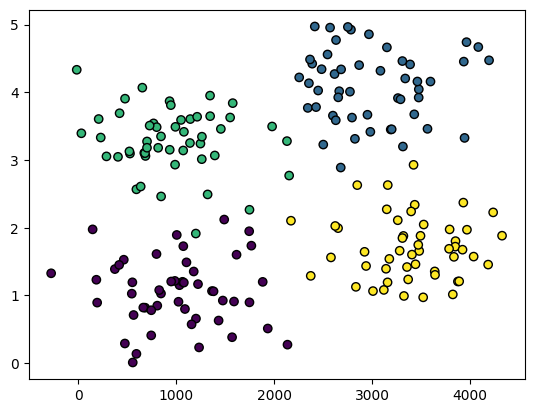

In [74]:
blob_centers = ([1, 1], [3, 4], [1, 3.3], [3.5, 1.8])
X, y = make_blobs(n_samples=200, 
                          centers=blob_centers, 
                          cluster_std=0.5,
                          random_state=0)

X[:, 0] *= 1000

plt.scatter(X[:, 0], X[:, 1], c=y,  edgecolors='black',linewidth=1)

Вы должны увидеть набор данных, состоящий из четырех кластеров, принадлежащий четырем классам:

То есть мы имеем дело с задачей множественной классификации. Для перцептрона это не проблема, нейросеть это очень универсальная модель, она может работать нативно и в множественном режиме. Давайте создадим первую версию нашей нейросети:

In [75]:
clf = MLPClassifier(hidden_layer_sizes=(6,), 
                    random_state=1).fit(X, y)

Обратите внимание, что при создании мы задаем количество слоев и количество нейронов в каждом из них с помощью кортежа _hidden\_layer\_sizes_. В данном случае имеем один скрытый слой в 6 нейронов. Если мы не зададим этот аргумент, то его значение по умолчанию - (100,), то есть один слой со ста нейронами. Этого для первой моедли будет довольно много.

Так как мы уже обучили модель, мы можем посмотреть значения весов нейронов, то есть внутренние параметры нейросети. Все они хранятся в поле _coefs\__, аналогично другим моделям машинного обучения в sklearn. Например, можно вывести веса отдельно для каждого слоя:

In [76]:
print("Веса между входным и скрытым слоем:")
print(clf.coefs_[0])
print("\nВеса между скрытым и выходным слоем:")
print(clf.coefs_[1])

Веса между входным и скрытым слоем:
[[-0.09809877  0.33667051 -0.82024119 -0.29720839 -0.56852789 -0.66056109]
 [-0.58903611 -0.31219238 -0.22424296  0.11423652 -0.18324369  0.37321781]]

Веса между скрытым и выходным слоем:
[[-0.51316658 -0.43365467  0.43189995  0.68148414]
 [-0.24370005  0.34328608  0.57835494  0.57889271]
 [-0.59713359 -0.67678056 -0.46609801  0.54011704]
 [-0.5769702  -0.10221922  0.75476969  0.00610289]
 [ 0.34285864 -0.25645017  0.33417991  0.47281254]
 [-0.7006119   0.35515533  0.80295119  0.33880635]]


Либо по каждому нейрону отдельно:

In [77]:
for i in range(len(clf.coefs_)):
    number_neurons_in_layer = clf.coefs_[i].shape[1]
    for j in range(number_neurons_in_layer):
        weights = clf.coefs_[i][:,j]
        print(i, j, weights, end=", ")
        print()
    print()

0 0 [-0.09809877 -0.58903611], 
0 1 [ 0.33667051 -0.31219238], 
0 2 [-0.82024119 -0.22424296], 
0 3 [-0.29720839  0.11423652], 
0 4 [-0.56852789 -0.18324369], 
0 5 [-0.66056109  0.37321781], 

1 0 [-0.51316658 -0.24370005 -0.59713359 -0.5769702   0.34285864 -0.7006119 ], 
1 1 [-0.43365467  0.34328608 -0.67678056 -0.10221922 -0.25645017  0.35515533], 
1 2 [ 0.43189995  0.57835494 -0.46609801  0.75476969  0.33417991  0.80295119], 
1 3 [0.68148414 0.57889271 0.54011704 0.00610289 0.47281254 0.33880635], 



Обратите внимание, что судя по выведенной информации, на выходном слое у нас четыре нейрона. Это обусловлено тем, что в датасете четыре класса. Количество классов всегда определяет количество нейронов на выходном слое. А на входном слое у нас два нейрона. Это потому, что в датасете всего две атрибута.

Веса нейронов смещения (bias) как и в других моделях хранятся в отдельном поле:


In [78]:
print("Веса смещения для скрытого слоя:")
print(clf.intercepts_[0])
print("\nВеса смещения для выходного слоя:")
print(clf.intercepts_[1])

Веса смещения для скрытого слоя:
[-0.55752645  0.60978582 -0.8640854   0.33258994 -0.18652436  0.05696655]

Веса смещения для выходного слоя:
[-0.29413473  0.49414359 -0.60792984 -0.11888525]


Давайте проанализируем, насколько хорошо работает наша модель. Для этого воспользуемся уже знакомой матрицей классификации:

In [79]:
confusion_matrix(y, clf.predict(X))

array([[ 0,  0,  0, 50],
       [ 0,  0,  0, 50],
       [ 0,  0,  0, 50],
       [ 0,  0,  0, 50]])

Мы видим, что как будто модель работает не совсем корректно и делает много ошибок. Чтобы убедиться в этом, изобразим классификацию на графике:

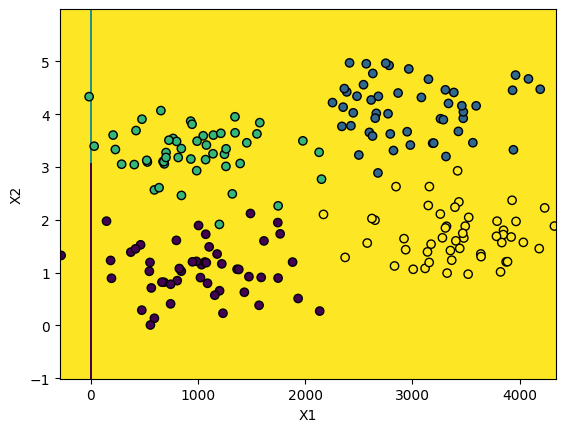

In [80]:
X0 = np.linspace(X[:, 0].min()-1,X[:, 0].max()+1, X.shape[0])
X1 = np.linspace(X[:, 1].min()-1,X[:, 1].max()+1, X.shape[0])
X0_grid, X1_grid = np.meshgrid(X0, X1)

y_predict = clf.predict(np.c_[X0_grid.ravel(),X1_grid.ravel()]).reshape(X0_grid.shape)
plt.pcolormesh(X0_grid, X1_grid, y_predict)

plt.scatter(X[:, 0], X[:, 1], c=y,  edgecolors='black',linewidth=1)
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

На примере данного кода познакомьтесь со способом изображения границы принятия решений для множественной классификации. Мы видим довольно странную картину:

Почти все точки модель относит к одному классу. А граница принятия решений почти всегда вертикальна. Что мы сделали не так? Для ответа на этот вопрос надо обратить внимание на подпись осей координат. Дело в том, что атрибуты в исходных данных имеют очень разные значения. $X_1$ измеряется в тысячах, а $X_2$ - в единицах. Это может стать проблемой для неекоторых моделей машинного обучения. И перцептрон - одна из них. Для корректной работы перцептрона данные нужно обязательно нормализовать. 

Для этого импортируем и воспользуемся объектом нормализации данных. Наример, таким:

In [81]:
from sklearn.preprocessing import StandardScaler 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = scaler.transform(X)
X_scaled = scaler.transform(X)

Давайте еще раз изобразим точки на графике, чтобы понять, как нормализация преобразовала наш датасет:

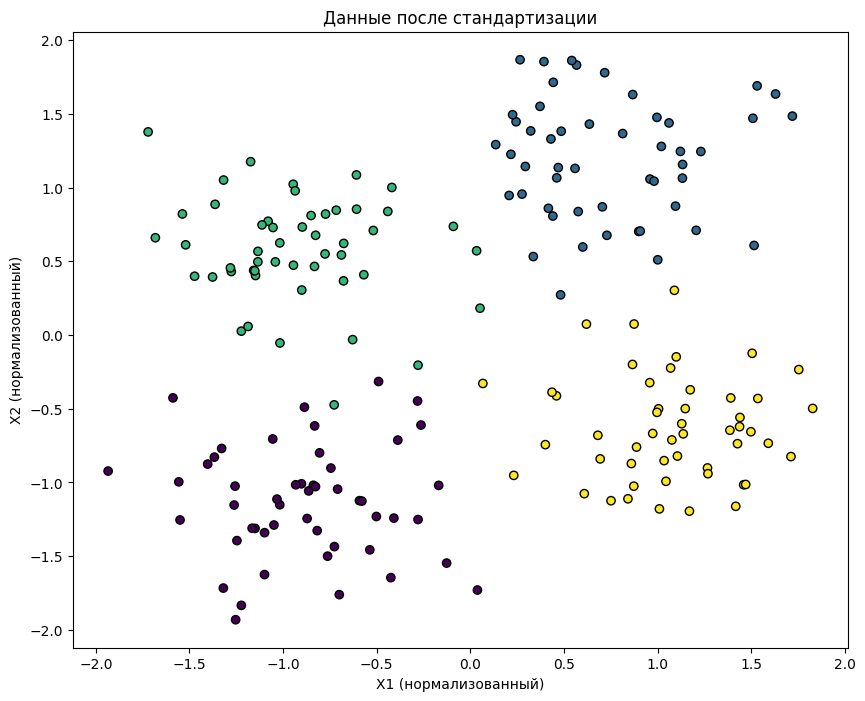

In [82]:
plt.figure(figsize=(10, 8))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, edgecolors='black', linewidth=1)
plt.xlabel('X1 (нормализованный)')
plt.ylabel('X2 (нормализованный)')
plt.title('Данные после стандартизации')
plt.show()

Само распределение как будто не изменилось, но обратите внимание на значения по осям. Теперь наш датасет имеет одинаковую размерность. Данные как будто "ужались" по горизонтали. Давайте посмотрим, повлияет ли это на качество обучения. Переобучим модель и выведем матрицу классификации:

In [83]:
clf = MLPClassifier(hidden_layer_sizes=(6,), random_state=1).fit(X_scaled, y)
print("Матрица ошибок после нормализации:")
print(confusion_matrix(y, clf.predict(X_scaled)))

Матрица ошибок после нормализации:
[[22  0 11 17]
 [ 0 38  0 12]
 [ 0  3 45  2]
 [ 0  5  0 45]]


/home/kai/ML_course/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Мы видим совершенно другую картину. Стало значительно лучше. Для большей уверенности изобразим классификацию на графике:

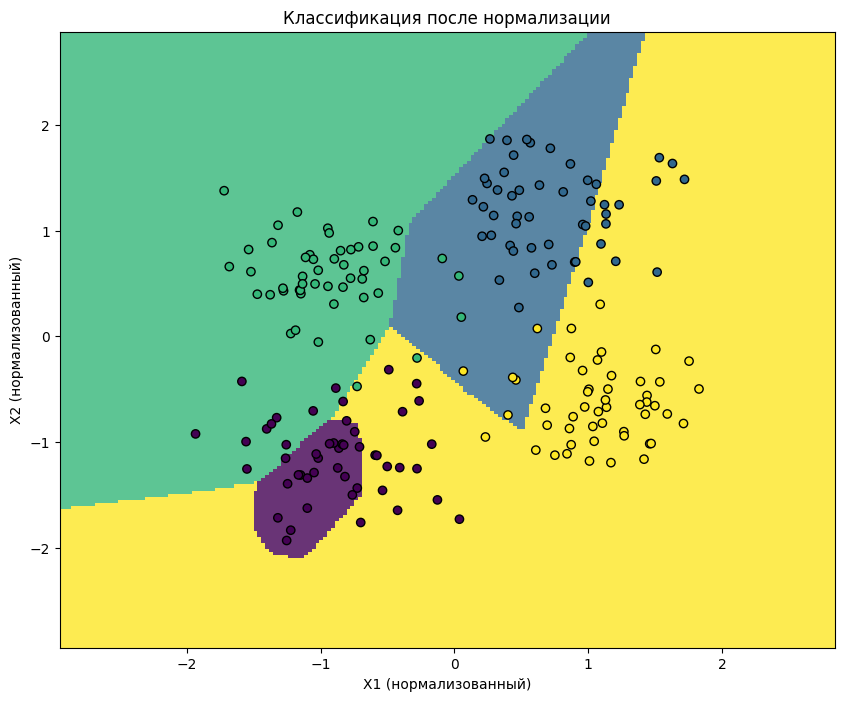

In [84]:
X0 = np.linspace(X_scaled[:, 0].min()-1, X_scaled[:, 0].max()+1, X_scaled.shape[0])
X1 = np.linspace(X_scaled[:, 1].min()-1, X_scaled[:, 1].max()+1, X_scaled.shape[0])
X0_grid, X1_grid = np.meshgrid(X0, X1)

y_predict = clf.predict(np.c_[X0_grid.ravel(), X1_grid.ravel()]).reshape(X0_grid.shape)
plt.figure(figsize=(10, 8))
plt.pcolormesh(X0_grid, X1_grid, y_predict, alpha=0.8)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, edgecolors='black', linewidth=1)
plt.xlabel('X1 (нормализованный)')
plt.ylabel('X2 (нормализованный)')
plt.title('Классификация после нормализации')
plt.show()

Мы видим, что регионы сооветствующих классов уже гораздо ближе к точкам обучающей выборки. При этом модель все еще делает довольно много ошибок. Как можно просто ее улучшить? вы могли обратить внимание, что при обучении модель выдавал предупреждение о раннем прерывании обучения. Мы уже сталкивались с такой ситуацией. Можно просто увеличить лимит итераций алгоритма обучения:

In [85]:
clf = MLPClassifier(hidden_layer_sizes=(6,), max_iter=10_000, verbose=True).fit(X_scaled, y)

Iteration 1, loss = 1.54347087
Iteration 2, loss = 1.53978319
Iteration 3, loss = 1.53610404
Iteration 4, loss = 1.53243937
Iteration 5, loss = 1.52878658
Iteration 6, loss = 1.52514377
Iteration 7, loss = 1.52152371
Iteration 8, loss = 1.51792302
Iteration 9, loss = 1.51434053
Iteration 10, loss = 1.51077531
Iteration 11, loss = 1.50722350
Iteration 12, loss = 1.50369745
Iteration 13, loss = 1.50018374
Iteration 14, loss = 1.49668448
Iteration 15, loss = 1.49319623
Iteration 16, loss = 1.48972035
Iteration 17, loss = 1.48625425
Iteration 18, loss = 1.48280464
Iteration 19, loss = 1.47936572
Iteration 20, loss = 1.47593703
Iteration 21, loss = 1.47251625
Iteration 22, loss = 1.46911849
Iteration 23, loss = 1.46573445
Iteration 24, loss = 1.46237166
Iteration 25, loss = 1.45901865
Iteration 26, loss = 1.45567548
Iteration 27, loss = 1.45235312
Iteration 28, loss = 1.44906120
Iteration 29, loss = 1.44578795
Iteration 30, loss = 1.44252545
Iteration 31, loss = 1.43927900
Iteration 32, los

Заодно здесь мы применим еще один аргумент конструктора объекта перцептрона - _verbose_. Он позволяет вывести подробную информацию про обучение модели. Проанализируйте полученную информацию и сделайте вывод.

Теперь можно вывести матрицу классификации. Сразу видно, что опять стало значительно лучше:

In [86]:
clf = MLPClassifier(hidden_layer_sizes=(6,), max_iter=10_000, verbose=True, random_state=1).fit(X_scaled, y)
print("\nМатрица ошибок после увеличения итераций:")
print(confusion_matrix(y, clf.predict(X_scaled)))

Iteration 1, loss = 1.55772482
Iteration 2, loss = 1.55299983
Iteration 3, loss = 1.54829381
Iteration 4, loss = 1.54360706
Iteration 5, loss = 1.53894010
Iteration 6, loss = 1.53430411
Iteration 7, loss = 1.52969980
Iteration 8, loss = 1.52511575
Iteration 9, loss = 1.52055201
Iteration 10, loss = 1.51602274
Iteration 11, loss = 1.51154009
Iteration 12, loss = 1.50707954
Iteration 13, loss = 1.50263954
Iteration 14, loss = 1.49822103
Iteration 15, loss = 1.49382404
Iteration 16, loss = 1.48945117
Iteration 17, loss = 1.48511055
Iteration 18, loss = 1.48079387
Iteration 19, loss = 1.47649973
Iteration 20, loss = 1.47222850
Iteration 21, loss = 1.46797950
Iteration 22, loss = 1.46375268
Iteration 23, loss = 1.45955297
Iteration 24, loss = 1.45538335
Iteration 25, loss = 1.45124561
Iteration 26, loss = 1.44713022
Iteration 27, loss = 1.44303725
Iteration 28, loss = 1.43896663
Iteration 29, loss = 1.43491796
Iteration 30, loss = 1.43089070
Iteration 31, loss = 1.42688916
Iteration 32, los

Этот вывод подтверждает и визуализация модели:

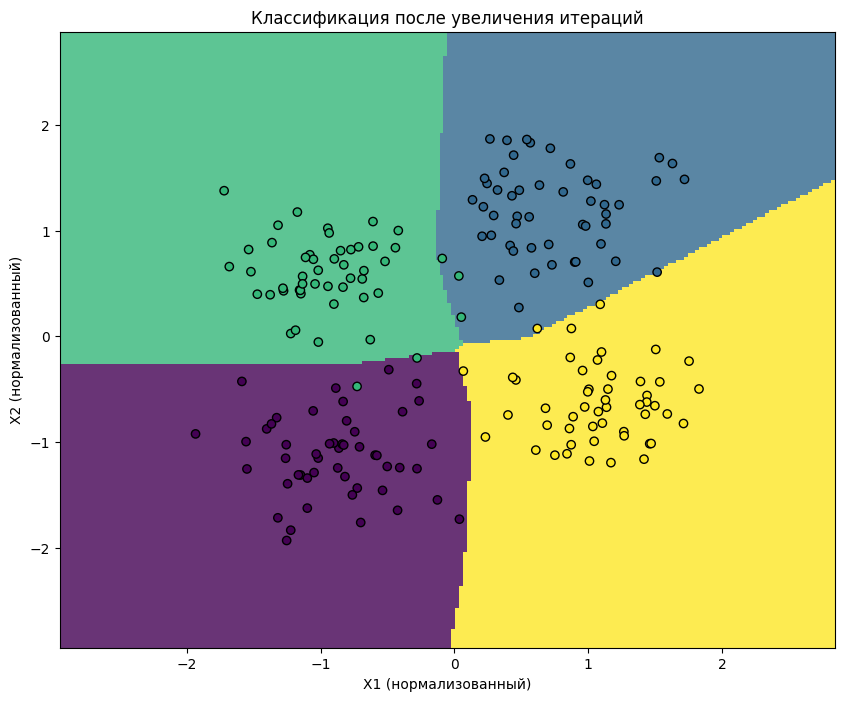

In [87]:
y_predict = clf.predict(np.c_[X0_grid.ravel(), X1_grid.ravel()]).reshape(X0_grid.shape)
plt.figure(figsize=(10, 8))
plt.pcolormesh(X0_grid, X1_grid, y_predict, alpha=0.8)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, edgecolors='black', linewidth=1)
plt.xlabel('X1 (нормализованный)')
plt.ylabel('X2 (нормализованный)')
plt.title('Классификация после увеличения итераций')
plt.show()

Для дальнейшего повышения точности можно увеличить количество скрытых слоев. Тогда получится уже глубокая нейросеть. Например, обучим перцептрон с тремя слоями:

In [88]:
clf = MLPClassifier(hidden_layer_sizes=(6, 6, 6), max_iter=10_000).fit(X_scaled, y)

In [89]:
print("Матрица ошибок для модели с тремя слоями:")
print(confusion_matrix(y, clf.predict(X_scaled)))

Матрица ошибок для модели с тремя слоями:
[[49  0  1  0]
 [ 0 50  0  0]
 [ 1  0 49  0]
 [ 0  0  0 50]]


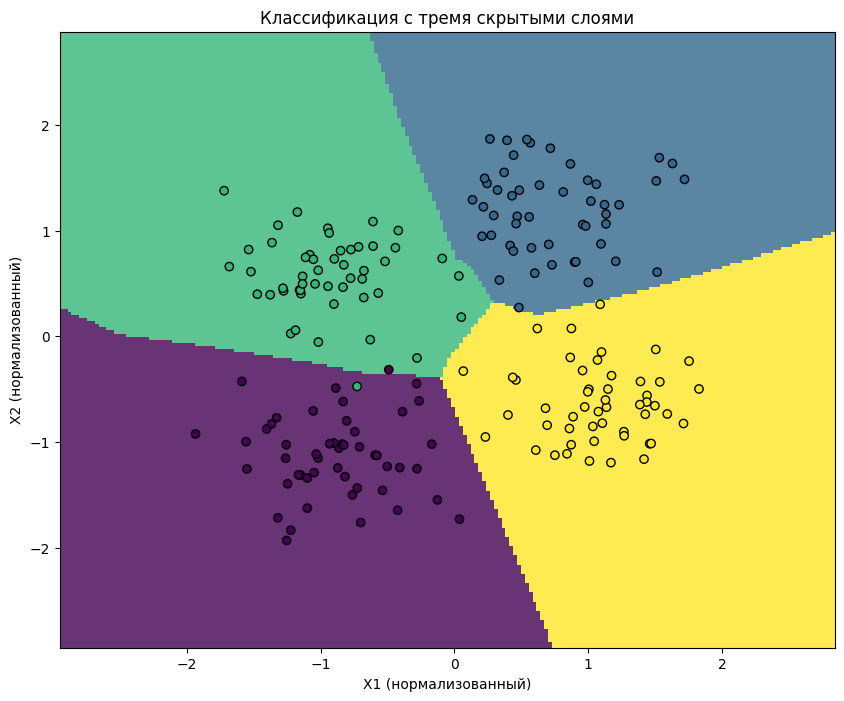

In [90]:
y_predict = clf.predict(np.c_[X0_grid.ravel(), X1_grid.ravel()]).reshape(X0_grid.shape)
plt.figure(figsize=(10, 8))
plt.pcolormesh(X0_grid, X1_grid, y_predict, alpha=0.8)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, edgecolors='black', linewidth=1)
plt.xlabel('X1 (нормализованный)')
plt.ylabel('X2 (нормализованный)')
plt.title('Классификация с тремя скрытыми слоями')
plt.show()

Из графика видно, что граница принятия решений еще больше соответствует обучающей выборке. Постройте матрицу классификации этой модели самостоятельно.

### Контрольные вопросы

**1. Что называют глубокой нейронной сетью?**  
Глубокой нейронной сетью называют нейронную сеть, имеющую **не менее двух скрытых слоёв** нейронов. Такие сети способны выявлять иерархические признаки: первые слои выделяют простые закономерности, последующие — более сложные абстракции. Глубина сети позволяет моделировать очень сложные нелинейные зависимости.

**2. Что такое архитектура нейронной сети?**  
Архитектура нейронной сети — это её структурная конфигурация, включающая: количество слоёв, количество нейронов в каждом слое, тип связей (полносвязная, свёрточная и т.д.), функции активации, способ соединения слоёв. Архитектура определяет, какую сложность зависимостей может уловить сеть и сколько параметров будет обучаться.

**3. Как количество нейронов и слоев влияет на качество моделирования?**  
- **Увеличение числа нейронов** в слое повышает способность сети запоминать детали обучающей выборки, но при избытке ведёт к переобучению.  
- **Увеличение числа слоёв** (глубины) позволяет моделировать более сложные иерархические зависимости, но требует больше данных и времени обучения, а также увеличивает риск переобучения.  
- Оптимальное количество нейронов и слоёв подбирается экспериментально (например, поиском по сетке).

**4. Как нейронная сеть решает задачи множественной классификации?**  
На выходном слое используется **softmax** в качестве функции активации, а количество нейронов равно числу классов. Сеть вычисляет для каждого класса вероятность принадлежности объекта к этому классу. Классом-победителем считается тот, у которого вероятность максимальна. Функция потерь — категориальная кросс-энтропия.

**5. В каких случаях следует применять перцептрон (MLP)?**  
- Когда данные имеют **сложную нелинейную структуру**, которую не могут уловить линейные модели (логистическая регрессия, линейный SVM).  
- Когда объём данных достаточно велик (обычно > 1000 примеров), чтобы избежать переобучения.  
- Когда требуется **высокая точность** и допустимо более долгое обучение.  
- При решении задач классификации, регрессии, а также при работе с многомерными данными, где признаки не имеют чёткой физической интерпретации.